In [2]:
import pandas as pd

In [9]:
books = pd.read_csv("data/books.csv")


In [10]:
books.head(2)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0


In [15]:
books.isnull().sum()

isbn13               0
isbn10               0
title                0
subtitle          4429
authors             72
categories          99
thumbnail          329
description        262
published_year       6
average_rating      43
num_pages           43
ratings_count       43
dtype: int64

In [21]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   str    
 2   title           6810 non-null   str    
 3   subtitle        2381 non-null   str    
 4   authors         6738 non-null   str    
 5   categories      6711 non-null   str    
 6   thumbnail       6481 non-null   str    
 7   description     6548 non-null   str    
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 638.6 KB


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


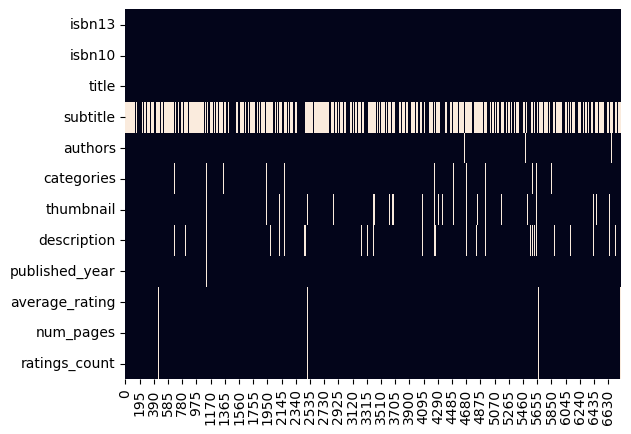

In [23]:
ax = plt.axes()
sns.heatmap(books.isna().transpose(), cbar=False, ax=ax)
plt.show()

In [24]:
import numpy as np 

In [ ]:
books["missing_description"] = np.where(books["description"].isna(), 1,0) # put 1 if description is there otherwise put 0
books["age_of_books"] = 2024- books["published_year"] 

In [29]:
colum_of_interest = ["num_pages", "age_of_books","missing_description","average_rating"]

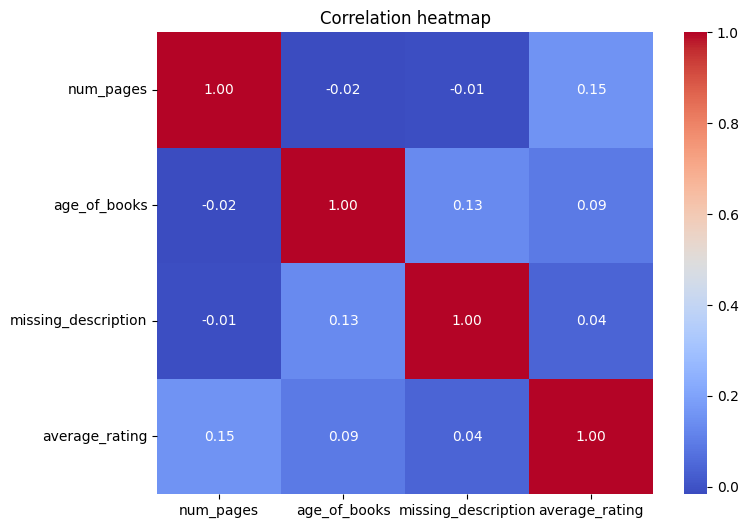

In [31]:
correlation_matrix = books[colum_of_interest].corr(method="spearman")
plt.figure(figsize=(8,6))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
heatmap.set_title("Correlation heatmap")
plt.show()

In [32]:
books_missing = books[~(books["description"].isna()) &
                      ~(books["num_pages"].isna()) &
                      ~(books["average_rating"].isna()) &
                      ~(books["published_year"].isna())
                      ]

In [36]:
books_missing.isna().sum()

isbn13                    0
isbn10                    0
title                     0
subtitle               4226
authors                  63
categories               33
thumbnail               214
description               0
published_year            0
average_rating            0
num_pages                 0
ratings_count             0
missing_description       0
age_of_books              0
dtype: int64

In [41]:
books_missing["categories"].value_counts().reset_index().sort_values("count", ascending=False)

,categories,count
0,Fiction,2523
1,Juvenile Fiction,534
2,Biography & Autobiography,391
3,History,258
4,Literary Criticism,164
...,...,...
526,Meditation,1
527,Gay men,1
528,Christian fiction,1
529,"Napoleonic Wars, 1800-1815",1


<Axes: xlabel='categories', ylabel='count'>

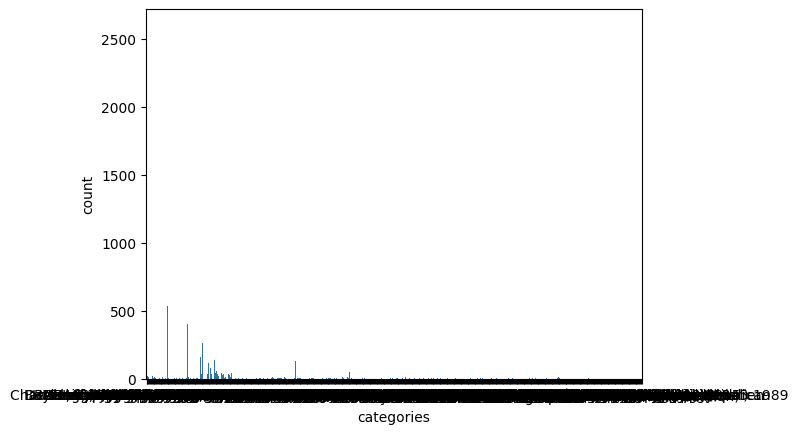

In [48]:
import seaborn as sns
sns.countplot(data=books, x='categories')


In [49]:
books_missing["words_in_description"] = books_missing["description"].str.split().str.len()

In [53]:
books_missing.loc[books_missing["words_in_description"].between(15,24),"description"]

10      One of Sidney Sheldon's most popular and bests...
32      Tells the story of three generations of Chines...
36      A magical and fantastic collection of early st...
57      A young drifter finds more than he bargained f...
68      A new 'The Doors of Perception' for the 21st c...
                              ...                        
6767    Everything from the fingerprints of the gods t...
6782    Displays one of America's leading physicist's ...
6783    Basics Illustration 01: Thinking Visually expl...
6789    Provides an introduction to the American artis...
6809    This is a jubilant and rewarding collection of...
Name: description, Length: 947, dtype: str

In [54]:
book_missing_25_words = books_missing[books_missing["words_in_description"] >=25]

In [56]:
book_missing_25_words.isna().sum()

isbn13                     0
isbn10                     0
title                      0
subtitle                3380
authors                   32
categories                30
thumbnail                166
description                0
published_year             0
average_rating             0
num_pages                  0
ratings_count              0
missing_description        0
age_of_books               0
words_in_description       0
dtype: int64

In [65]:
book_missing_25_words["title_and_subtitle"] = (
    book_missing_25_words["title"] +
    np.where(
        book_missing_25_words["subtitle"].notna(),
        ": " + book_missing_25_words["subtitle"],
        ""
    )
)

In [67]:
book_missing_25_words.head(2)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_books,words_in_description,title_and_subtitle
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0,199,Gilead
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0,205,Spider's Web: A Novel


In [68]:
book_missing_25_words["tagged_description"] = book_missing_25_words[["isbn13", "description"]].astype(str).agg(" ".join, axis =1)

In [69]:
book_missing_25_words.head(2)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_books,words_in_description,title_and_subtitle,tagged_description
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0,199,Gilead,9780002005883 A NOVEL THAT READERS and critics...
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0,205,Spider's Web: A Novel,9780002261982 A new 'Christie for Christmas' -...


In [70]:
(
    book_missing_25_words.drop(["subtitle","missing_description","age_of_books","words_in_description"], axis=1)
    .to_csv("books_cleaned.csv", index = False)
)